# Part 1: NumPyro and the Bayesian Workflow

We start from basic Bayesian inference in **NumPyro**, then show how to generate and check data using **Predictive** and the **Bayesian workflow**.

## 1.1 Bayesian inference with NumPyro: a minimal example

NumPyro lets you specify a **generative model** (priors and likelihood) and then run inference (e.g. MCMC or SVI). Key ideas:

- **Model**: a Python function that calls `numpyro.sample(...)` for parameters and for data given parameters. The joint distribution is implicit in the execution trace.
- **NUTS**: No-U-Turn Sampler (Hamiltonian Monte Carlo) to draw samples from the posterior.
- **ArviZ**: a library for diagnosing and visualizing MCMC (posteriors, HDI, etc.).

We use **scalar linear regression**: $y = a x + b + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. We observe $(x, y)$ and infer $a$, $b$, and $\sigma$.

In [1]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax.random as jr

def linear_regression_model(x, y=None):
    """y = a*x + b + noise. We observe (x, y); infer a, b, sigma."""
    a = numpyro.sample("a", dist.Normal(0.0, 2.0))
    b = numpyro.sample("b", dist.Normal(0.0, 2.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = a * x + b
    numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

In [2]:
# Generate synthetic data: y = a*x + b + noise
key = jr.PRNGKey(0)
a_true, b_true = 1.5, -0.5
sigma_true = 0.3
n = 80
key, kx, kn = jr.split(key, 3)
x_data = jr.uniform(kx, (n,), minval=-2.0, maxval=2.0)
y_data = a_true * x_data + b_true + sigma_true * jr.normal(kn, (n,))

print("True: a =", a_true, ", b =", b_true, ", sigma =", sigma_true)

True: a = 1.5 , b = -0.5 , sigma = 0.3


In [3]:
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(linear_regression_model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000)
mcmc.run(jr.PRNGKey(1), x=x_data, y=y_data)
posterior = mcmc.get_samples()

sample: 100%|██████████| 1500/1500 [00:00<00:00, 3898.71it/s, 3 steps of size 8.16e-01. acc. prob=0.91]


/Users/levinema/Projects/research/dynestyx/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/Users/levinema/Projects/research/dynestyx/.venv/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (1000) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


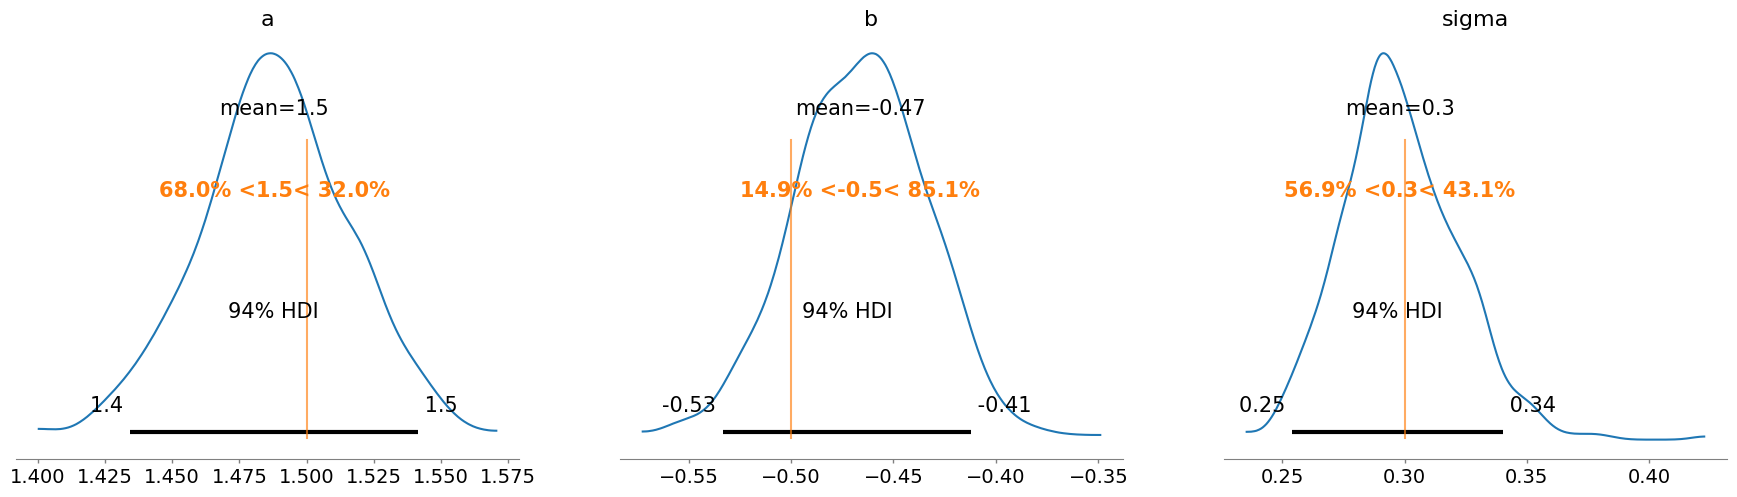

In [4]:
import arviz as az

# ArviZ expects (num_samples, *shape); our samples are 1D so we add a dim for ArviZ
posterior_for_az = {k: v[..., None] if v.ndim == 1 else v for k, v in posterior.items()}
idata = az.from_dict(posterior=posterior_for_az)
az.plot_posterior(idata, var_names=["a", "b", "sigma"], ref_val=[a_true, b_true, sigma_true]);

## 1.2 Generating data with Predictive, and the Bayesian workflow

Instead of hand-writing $y = a x + b + \text{noise}$, we can **generate data from the model** using NumPyro's `Predictive`. The data-generating process then matches the model exactly. We can also use `Predictive` for **prior predictive** and **posterior predictive** samples—core steps in the [Bayesian workflow](https://arxiv.org/abs/2011.01808) (model building, prior predictive checks, fit, posterior predictive checks).

In [5]:
from numpyro.infer import Predictive

x_grid = jnp.linspace(-2, 2, 50)

# (1) Generate data from the model with fixed parameters (like our "true" data)
prior_predictive_fixed = Predictive(
    linear_regression_model,
    num_samples=4,
    params={"a": jnp.array(a_true), "b": jnp.array(b_true), "sigma": jnp.array(sigma_true)},
)
prior_pred_fixed = prior_predictive_fixed(jr.PRNGKey(2), x=x_grid)

In [6]:
# (2) Prior predictive: sample (a, b, sigma) from prior, then y | x
prior_predictive_full = Predictive(linear_regression_model, num_samples=20)
prior_pred_full = prior_predictive_full(jr.PRNGKey(3), x=x_grid)

In [7]:
# (3) Posterior predictive: sample (a, b, sigma) from posterior, then y | x
posterior_predictive = Predictive(
    linear_regression_model,
    posterior_samples=posterior,
    num_samples=200,
)
post_pred = posterior_predictive(jr.PRNGKey(4), x=x_grid)

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_98808/929956073.py:2: UserWarning: Sample's batch dimension size 1000 is different from the provided 200 num_samples argument. Defaulting to 1000.
  posterior_predictive = Predictive(


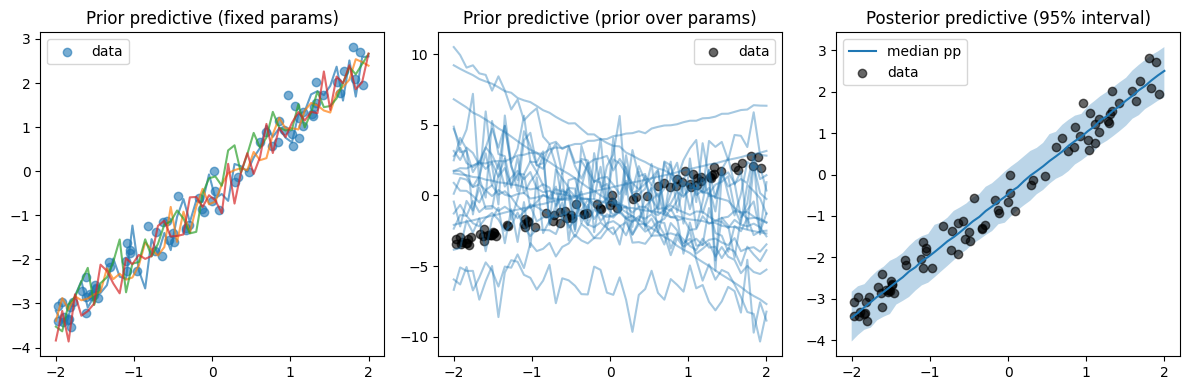

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(x_data, y_data, alpha=0.6, label="data")
for i in range(min(4, prior_pred_fixed["y"].shape[0])):
    axes[0].plot(x_grid, prior_pred_fixed["y"][i], alpha=0.7)
axes[0].set_title("Prior predictive (fixed params)")
axes[0].legend()

for i in range(prior_pred_full["y"].shape[0]):
    axes[1].plot(x_grid, prior_pred_full["y"][i], alpha=0.4, color="C0")
axes[1].scatter(x_data, y_data, alpha=0.6, color="black", label="data")
axes[1].set_title("Prior predictive (prior over params)")
axes[1].legend()

y_pp = post_pred["y"]
axes[2].fill_between(
    x_grid,
    jnp.percentile(y_pp, 2.5, axis=0),
    jnp.percentile(y_pp, 97.5, axis=0),
    alpha=0.3,
)
axes[2].plot(x_grid, jnp.median(y_pp, axis=0), color="C0", label="median pp")
axes[2].scatter(x_data, y_data, alpha=0.6, color="black", label="data")
axes[2].set_title("Posterior predictive (95% interval)")
axes[2].legend()
plt.tight_layout()
plt.show()

**Next:** [Part 2 — Dynestyx: discrete-time dynamical systems](../02_dynestyx_discrete_intro.ipynb)